# Problem Formulation: Air Quality & Public Health Risk Forecasting

**Objective:**  
Develop predictive models to forecast days exceeding ozone levels and to identify early-warning indicators for high-risk areas.

**Motivation:**  
- Protect public health by anticipating periods of high pollution.  
- Support environmental policy and preventive actions.  
- Utilize temporal and spatial data to interpret risks and changes at state and county levels.

**Key Questions:**  
1. Can counties with persistent high risk be predicted years in advance?  
2. How do temporal pollution patterns differ between urban and rural areas?  
3. Are regulatory effects uniformly distributed across states?  
4. Can early-warning thresholds be defined using rolling statistics?  
5. How does air quality volatility correlate with long-term health outcomes?


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

plt.style.use("seaborn-v0_8")
sns.set_context("notebook")

In [22]:
DATA_PATH = "../data/processed/air_quality_data_processed.csv"
df = pd.read_csv(DATA_PATH)

print("Columns in dataset:", df.columns.tolist())
print("Dataset shape:", df.shape)
df.head()


Columns in dataset: ['state_fips', 'state', 'county_fips', 'county', 'year', 'measure_id', 'measure_name', 'value', 'data_origin', 'monitor_only', 'value_missing', 'value_lag_1', 'value_lag_3', 'rolling_mean_3', 'year_norm', 'high_risk']
Dataset shape: (218635, 16)


,state_fips,state,county_fips,county,year,measure_id,measure_name,value,data_origin,monitor_only,value_missing,value_lag_1,value_lag_3,rolling_mean_3,year_norm,high_risk
0,1,Alabama,1001,Autauga,2001,292,Number of days with maximum 8-hour average ozo...,3.000000,Monitor & Modeled,False,0,NaN,NaN,NaN,2,0
1,1,Alabama,1001,Autauga,2001,293,Number of person-days with maximum 8-hour aver...,134667.000000,Monitor & Modeled,False,0,3.0,NaN,NaN,2,1
2,1,Alabama,1001,Autauga,2001,294,Percent of days with PM2.5 levels over the Nat...,0.000000,Monitor & Modeled,False,0,134667.0,NaN,44890.000000,2,0
3,1,Alabama,1001,Autauga,2001,295,Number of person-days with PM2.5 over the Nati...,0.000000,Monitor & Modeled,False,0,0.0,3.0,44889.000000,2,0
4,1,Alabama,1001,Autauga,2001,296,Annual average ambient concentrations of PM 2....,13.186807,Monitor & Modeled,False,0,0.0,134667.0,4.395602,2,0


**Smart Data Filtering & Feature Selection**

To ensure scientific accuracy, we filter the data to include only Ozone Exceedance Days and exclude population-weighted metrics that caused the "billions" scale error.

In [24]:
mask = (df['measure_name'].str.contains('Ozone', case=False)) & \
        (df['measure_name'].str.contains('days', case=False)) & \
        (~df['measure_name'].str.contains('person', case=False))

df_filtered = df[mask].copy()

features = ["value_lag_1", "value_lag_3", "rolling_mean_3", "year_norm"]
target = "value"

df_model = df_filtered.dropna(subset=features + [target])

print(f"Rows after filtering: {len(df_filtered)}")
print(f"Samples for training (n_samples): {len(df_model)}")

Rows after filtering: 44540
Samples for training (n_samples): 41446


**Model Training (Random Forest)**

We use Random Forest Regression to capture non-linear relationships between past pollution levels and future risks.

In [25]:
X = df_model[features]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)

y_pred = rf_reg.predict(X_test)

**Final Performance Metrics**

These metrics reflect the actual accuracy of the model in predicting "Days."

In [28]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f} Days")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} Days")

R² Score: 0.6098
Mean Absolute Error (MAE): 2.17 Days
Root Mean Squared Error (RMSE): 5.50 Days


**Visualizing Model Insights**

We analyze the relationship between predicted and actual values and determine which features are the most influential.

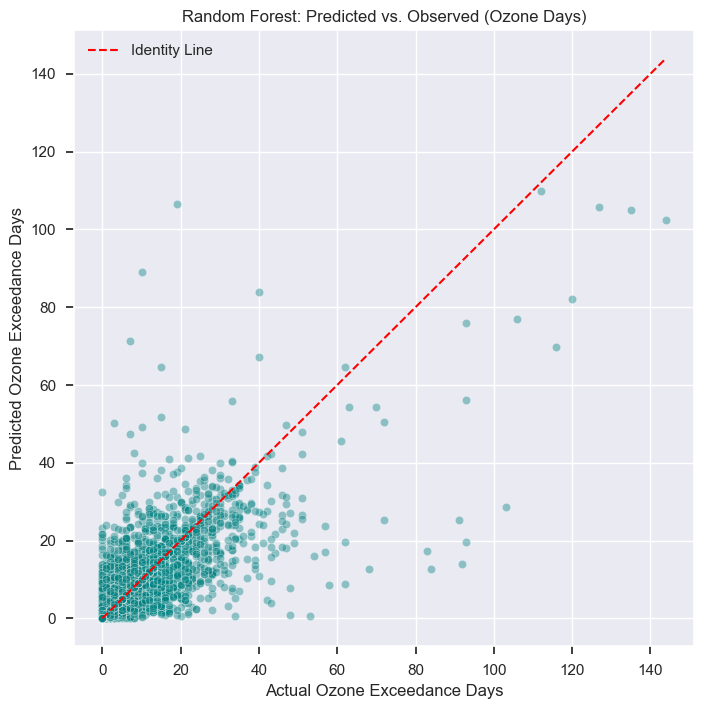

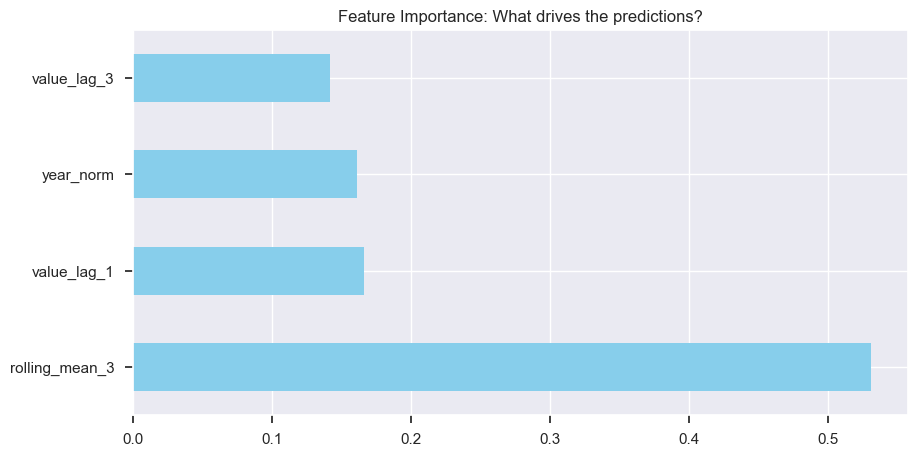

In [30]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, color='teal')
plt.plot([0, y_test.max()], [0, y_test.max()], linestyle="--", color="red", label="Identity Line")
plt.xlabel("Actual Ozone Exceedance Days")
plt.ylabel("Predicted Ozone Exceedance Days")
plt.title("Random Forest: Predicted vs. Observed (Ozone Days)")
plt.legend()
plt.show()

importance = pd.Series(rf_reg.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
importance.plot(kind='barh', color='skyblue')
plt.title("Feature Importance: What drives the predictions?")
plt.show()

## Emerging Research Questions

1. Can counties with persistent high risk be predicted years in advance?  
2. How do temporal pollution patterns differ between urban and rural areas?  
3. Are regulatory effects uniformly distributed across states?  
4. Can early-warning thresholds be defined using rolling statistics?  
5. How does air quality volatility correlate with long-term health outcomes?
